# Pola Konsumsi Air Global 2000–2024

**Kelompok:** 8

**Anggota:**
- Muhammad Mikail Laurana - 5027261053
- Naswa Fitri Auliyah - 5027261080
- Arkan Putra Ridhana - 5027261092

**Topik:** Analisis pola konsumsi air, penggunaan sektor (pertanian/industri/rumah tangga), dan tingkat kelangkaan air di 20 negara periode 2000–2024

## Latar Belakang dan Pertanyaan

Air itu kebutuhan dasar yang sering dianggap remeh, padahal makin lama makin
tertekan karena jumlah penduduk yang terus naik, industri yang berkembang,
dan cuaca yang makin tidak menentu. Kami tertarik pakai dataset ini karena
datanya cukup lengkap, ada 20 negara yang dipantau selama 25 tahun terakhir,
jadi bisa kelihatan gimana pola pemakaian airnya berubah dan sektor mana
yang paling banyak "makan" air.

Pertanyaan yang ingin kami jawab:
1. Bagaimana perbandingan penggunaan air bersih di berbagai sektor ekonomi satu negara?
2. Bagaimana perbedaan penggunaan air bersih tahun ke tahun di satu negara?
3. Bagaimana perbedaan rata-rata konsumsi air, curah hujan, dan penurunan air tanah pada setiap tingkat kelangkaan air?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv("data/cleaned_global_water_consumption.csv")
print(df.shape)
df.head()

(500, 10)


,Country,Year,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,Argentina,2000,481.490000,235.431429,48.550000,20.844286,30.100000,1288.698571,3.255714,Moderate
1,Argentina,2001,455.063000,299.551000,48.465000,26.943000,22.550000,1371.729000,3.120000,Moderate
2,Argentina,2002,482.749231,340.124615,50.375385,29.042308,23.349231,1590.305385,2.733846,Moderate
3,Argentina,2003,452.660000,326.756667,49.086667,30.476000,24.440000,1816.012667,2.708000,Moderate
4,Argentina,2004,634.566000,230.346000,38.670000,36.670000,23.924000,815.998000,1.902000,Moderate


Tiap baris di dataset ini nunjukkin data satu negara di satu tahun tertentu.
Totalnya ada 500 baris, hasil dari 20 negara yang dicatat selama 25 tahun
(2000–2024), dengan 10 kolom yang isinya total konsumsi air, konsumsi per
kapita, persentase pemakaian per sektor (pertanian/industri/rumah tangga),
curah hujan tahunan, tingkat penurunan air tanah, sama level kelangkaan
airnya (Low/Moderate/High)

---
*Bagian 4–6 dikerjakan oleh: Arkan Putra Ridhana*

## 4. Deskripsi Data dan Kamus Data
Sumber Data:  
https://www.kaggle.com/datasets/atharvasoundankar/global-water-consumption-dataset-2000-2024  
Lisensi:  
No Copyright  
Author: -  
Collaborator: Atharva Soundankar  
Waktu Pengumpulan Data: 2000-2024  
Bagaimana Pengumpulan Data: Tidak tertera  

Penjelasan Data:
| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `Country` | Nama negara tempat pengukuran diambil | Kualitatif | Nominal | – | Argentina |
| `Year` | Tahun pencatatan data (2000–2024) | Kuantitatif diskrit | Interval | Tahun | 2000 |
| `Total Water Consumption (Billion Cubic Meters)` | Total konsumsi air bersih tahunan suatu negara | Kuantitatif kontinu | Rasio | Miliar m³ | 481.49 |
| `Per Capita Water Use (Liters per Day)` | Rata-rata konsumsi air bersih harian per orang | Kuantitatif kontinu | Rasio | Liter/hari | 235.43 |
| `Agricultural Water Use (%)` | Persentase penggunaan air di sektor pertanian | Kuantitatif kontinu | Rasio | % | 48.55 |
| `Industrial Water Use (%)` | Persentase penggunaan air di sektor industri | Kuantitatif kontinu | Rasio | % | 20.84 |
| `Household Water Use (%)` | Persentase penggunaan air di sektor rumah tangga | Kuantitatif kontinu | Rasio | % | 30.10 |
| `Rainfall Impact (Annual Precipitation in mm)` | Curah hujan tahunan yang diterima negara tersebut | Kuantitatif kontinu | Rasio | mm | 1288.70 |
| `Groundwater Depletion Rate (%)` | Tingkat penurunan/penyusutan cadangan air tanah tahunan | Kuantitatif kontinu | Rasio | % | 3.26 |
| `Water Scarcity Level` | Tingkat keparahan kelangkaan air bersih | Kualitatif | Ordinal | – | Moderate |

## 5. Pemeriksaan Kualitas Data

Pada bagian ini kami memeriksa tipe data, data kosong, duplikat, dan rentang nilai untuk memastikan dataset layak dianalisis.

In [2]:
print("Informasi tipe data: ")
df.info()

print("\nJumlah data kosong per kolom: ")
print(df.isna().sum())

print("\nJumlah baris duplikat: ")
print(df.duplicated().sum())

print("\n Ringkasan nilai min max: ")
print(df.describe().T[['min', 'max']])

Informasi tipe data: 
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         500 non-null    str    
 1   Year                                            500 non-null    int64  
 2   Total Water Consumption (Billion Cubic Meters)  500 non-null    float64
 3   Per Capita Water Use (Liters per Day)           500 non-null    float64
 4   Agricultural Water Use (%)                      500 non-null    float64
 5   Industrial Water Use (%)                        500 non-null    float64
 6   Household Water Use (%)                         500 non-null    float64
 7   Rainfall Impact (Annual Precipitation in mm)    500 non-null    float64
 8   Groundwater Depletion Rate (%)                  500 non-null    float64
 9   Water Scarcity Level            

### Rangkuman Kualitas Data

- **Tidak ada data kosong** pada semua kolom (500 non-null dari 500 baris).
- **Tidak ada baris duplikat**.
- Tipe data sudah sesuai: kolom `Year` bertipe `int64`, kolom numerik lain `float64`, dan kolom `Country` serta `Water Scarcity Level` bertipe `str`.
- Rentang nilai min–max sudah masuk akal, misalnya:
  - `Year`: 2000–2024
  - `Total Water Consumption`: 129,64–798,42 miliar m³
  - `Per Capita Water Use`: 111,71–404,35 liter/hari
  - `Groundwater Depletion Rate`: 1,30%–4,32%

**Keputusan:** Tidak ada data yang perlu dihapus atau diperbaiki. Dataset siap dianalisis.

## 6. Statistik Deskriptif Variabel Numerik

Kami memilih tiga kolom numerik utama: `total_consumption`, `per_capita`, dan `rainfall`. Untuk setiap kolom dihitung ukuran pemusatan (mean, median, modus), penyebaran (min, max, jangkauan, varians, simpangan baku), dan letak (Q1, Q3, IQR).

In [3]:
kolom_numerik = [
    'Total Water Consumption (Billion Cubic Meters)',
    'Per Capita Water Use (Liters per Day)',
    'Rainfall Impact (Annual Precipitation in mm)'
]
ringkasan = []
for col in kolom_numerik:
    data = df[col]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    
    ringkasan.append({
        'Variabel': col,
        'Rata-rata': data.mean(),
        'Median': data.median(),
        'Modus': data.mode()[0],
        'Min': data.min(),
        'Max': data.max(),
        'Jangkauan': data.max() - data.min(),
        'Varians': data.var(),
        'Simpangan Baku': data.std(),
        'Q1': q1,
        'Q3': q3,
        'IQR': q3 - q1
    })
tabel_ringkasan = pd.DataFrame(ringkasan).set_index('Variabel').T
display(tabel_ringkasan)
sampel = df['Per Capita Water Use (Liters per Day)'].head(10)
n = len(sampel)
rerata_sampel = sampel.mean()
kuadrat_selisih = [(x - rerata_sampel)**2 for x in sampel]
varians_manual = sum(kuadrat_selisih) / (n - 1)
std_manual = varians_manual ** 0.5

print("Hasil Perhitungan Manual (10 Baris Pertama): ")
print("Rata-rata Sampel :", rerata_sampel)
print("Varians Manual   :", varians_manual, "| Pandas:", sampel.var())
print("Std Dev Manual   :", std_manual, "| Pandas:", sampel.std())

Variabel,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Rainfall Impact (Annual Precipitation in mm)
Rata-rata,501.224430,276.004782,1544.824300
Median,502.197154,276.430556,1537.537724
Modus,129.636667,111.708333,700.230000
Min,129.636667,111.708333,700.230000
Max,798.418000,404.350000,2533.678000
Jangkauan,668.781333,292.641667,1833.448000
Varians,9231.162101,1820.694137,85723.980639
Simpangan Baku,96.078937,42.669593,292.786579
Q1,441.447385,250.225406,1353.734583
Q3,563.849594,300.221750,1746.402425


Hasil Perhitungan Manual (10 Baris Pertama): 
Rata-rata Sampel : 246.28697107
Varians Manual   : 4478.414959259256 | Pandas: 4478.414959259256
Std Dev Manual   : 66.92096053748224 | Pandas: 66.92096053748224


### Interpretasi Statistik Deskriptif
1. Total Water Consumption:
Rata rata dan median nya mirip, yang menunjukan sebaran data nya simetris atau tidak miring
Rata-rata: **501,22 miliar m³**, Median: **502,20 miliar m³**.

3. Per Capita Water Use
Rata rata dan median berdekatan, yang menunjukan distribusi simetris.
Rata-rata: **276,00 liter/hari**, Median: **276,43 liter/hari**.

5. Rainfall Impact
Rata rata curah hujan tahunan sebesar 1544.82 mm/tahun dengan median 1537.54 mm/tahun (sebaran simetris)
Rata-rata: **1544,82 mm/tahun**, Median: **1537,54 mm/tahun**.

Hasil perhitungan manual varians dan simpangan baku sampel pada 10 baris pertama kolom Per Capita Water Use dengan pembagi n - 1 = 9:
- **Rata-rata Sampel:** `246.2870`
- **Varians Manual:** `4478.4150` (Cocok 100% dengan `.var()` Pandas)
- **Std Dev Manual:** `66.9210` (Cocok 100% dengan `.std()` Pandas)

---
*Bagian 7–10 dikerjakan oleh: Muhammad Mikail Laurana*

## 7. Ringkasan Variabel Kategorik

Pada bagian ini kami meringkas kolom kategorik **Water Scarcity Level** untuk melihat distribusi tingkat kelangkaan air pada seluruh observasi.

In [4]:
print(df["Water Scarcity Level"].value_counts())
print(df["Water Scarcity Level"].value_counts(normalize=True) * 100)

Water Scarcity Level
Moderate    360
Low         122
High         18
Name: count, dtype: int64
Water Scarcity Level
Moderate    72.0
Low         24.4
High         3.6
Name: proportion, dtype: float64


## **8. VISUALISASI DATA**

Bagian ini menampilkan empat jenis visualisasi:
1. **Histogram** untuk melihat sebaran dua kolom numerik
2. **Boxplot** untuk mendeteksi pencilan
3. **Diagram batang** untuk kolom kategorik
4. **Scatter plot** untuk melihat hubungan dua kolom numerikm

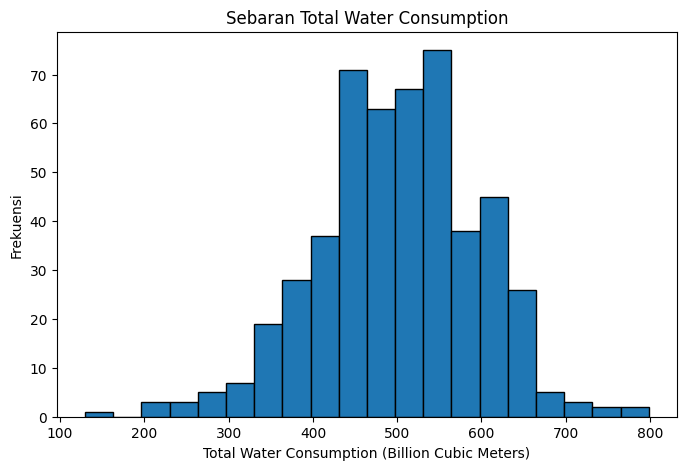

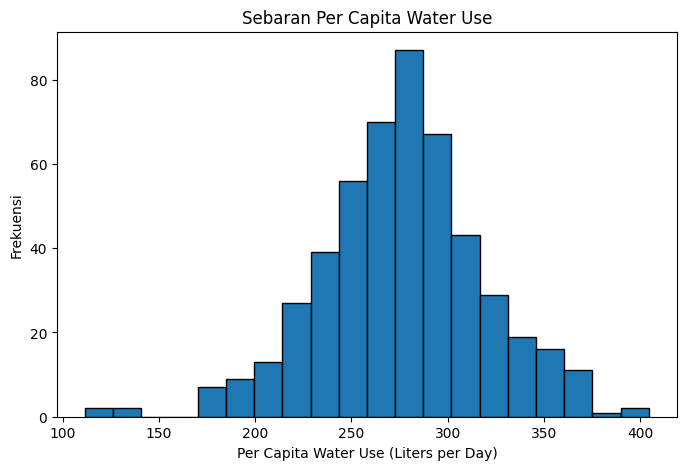

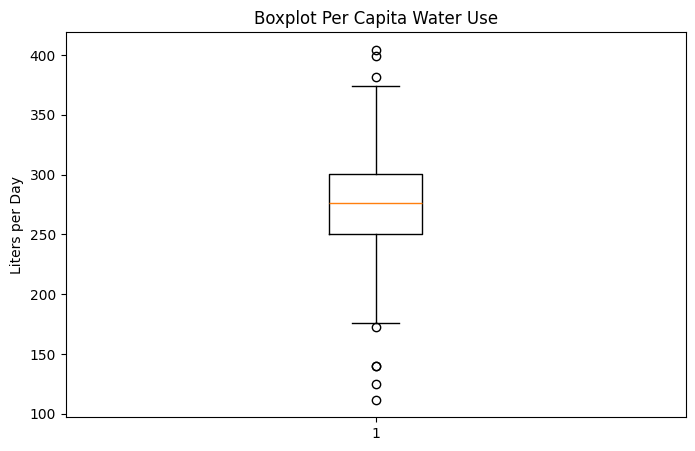

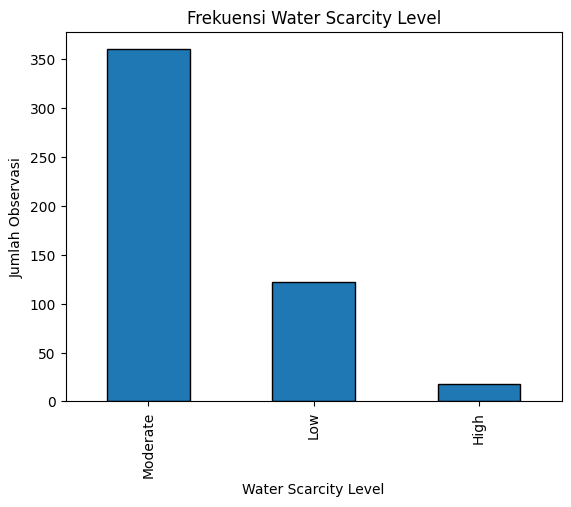

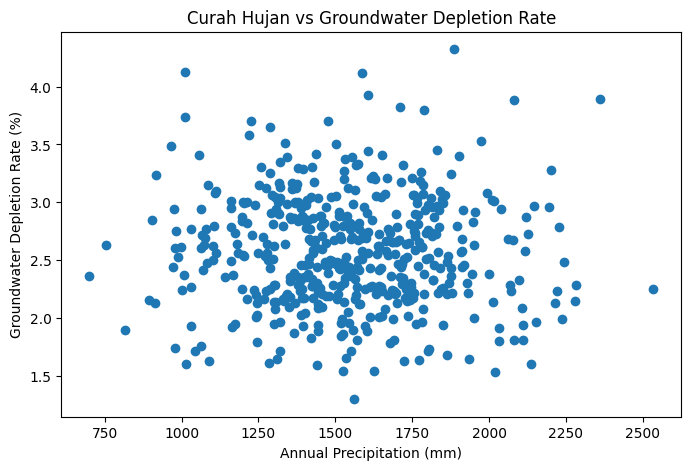

In [5]:
# Histogram 1
plt.figure(figsize=(8,5))
plt.hist(df["Total Water Consumption (Billion Cubic Meters)"], bins=20, edgecolor="black")
plt.title("Sebaran Total Water Consumption")
plt.xlabel("Total Water Consumption (Billion Cubic Meters)")
plt.ylabel("Frekuensi")
plt.show()

# Histogram 2
plt.figure(figsize=(8,5))
plt.hist(df["Per Capita Water Use (Liters per Day)"], bins=20, edgecolor="black")
plt.title("Sebaran Per Capita Water Use")
plt.xlabel("Per Capita Water Use (Liters per Day)")
plt.ylabel("Frekuensi")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df["Per Capita Water Use (Liters per Day)"])
plt.title("Boxplot Per Capita Water Use")
plt.ylabel("Liters per Day")
plt.show()

# Diagram batang kategorik
df["Water Scarcity Level"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Frekuensi Water Scarcity Level")
plt.xlabel("Water Scarcity Level")
plt.ylabel("Jumlah Observasi")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    df["Rainfall Impact (Annual Precipitation in mm)"],
    df["Groundwater Depletion Rate (%)"]
)
plt.title("Curah Hujan vs Groundwater Depletion Rate")
plt.xlabel("Annual Precipitation (mm)")
plt.ylabel("Groundwater Depletion Rate (%)")
plt.show()

## 9. Kesimpulan

### Jawaban Pertanyaan Awal

**1. Bagaimana perbandingan penggunaan air bersih di berbagai sektor ekonomi satu negara?**

Dari rata-rata seluruh data, sektor **pertanian** mengonsumsi air paling banyak yaitu sekitar **50%**, diikuti sektor **industri** sekitar **27%**, dan **rumah tangga** sekitar **24%**. Artinya, air paling banyak dipakai untuk irigasi dan kegiatan pertanian, sementara kebutuhan rumah tangga justru porsinya paling kecil. Ini menunjukkan bahwa kebijakan penghematan air sebaiknya fokus pada sektor pertanian.

Rata-rata penggunaan air per sektor (%):
Agricultural Water Use (%)    50.180829
Industrial Water Use (%)      27.792837
Household Water Use (%)       24.832515
dtype: float64


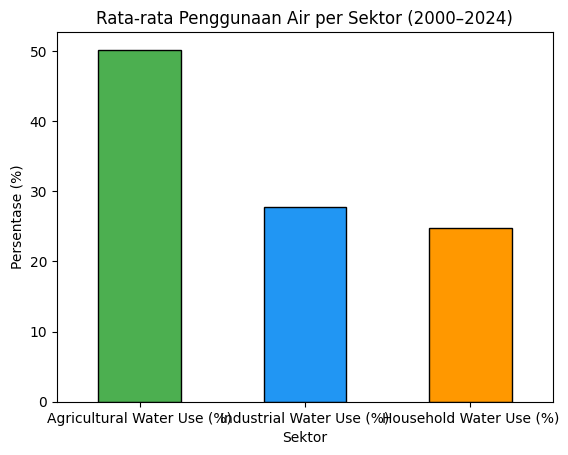

In [6]:
# Rata-rata penggunaan air per sektor
sektor_means = df[["Agricultural Water Use (%)", "Industrial Water Use (%)", "Household Water Use (%)"]].mean()
print("Rata-rata penggunaan air per sektor (%):")
print(sektor_means)

# Visualisasi diagram batang
sektor_means.plot(kind="bar", edgecolor="black", color=["#4CAF50","#2196F3","#FF9800"])
plt.title("Rata-rata Penggunaan Air per Sektor (2000–2024)")
plt.xlabel("Sektor")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.show()

**2. Bagaimana perbedaan penggunaan air bersih tahun ke tahun di satu negara?**

Sebagai contoh, di **Indonesia** total konsumsi air berfluktuasi dari tahun 2000–2024. Nilai terendah terjadi pada tahun **2017** sebesar **719** miliar m³, sedangkan tertinggi pada tahun **2002** sebesar **335** miliar m³. Pola ini menunjukkan konsumsi air tidak selalu naik setiap tahun, melainkan dipengaruhi faktor musiman, kebijakan, dan kondisi ekonomi. Tren serupa juga terlihat di negara lain seperti Argentina dan Brazil.

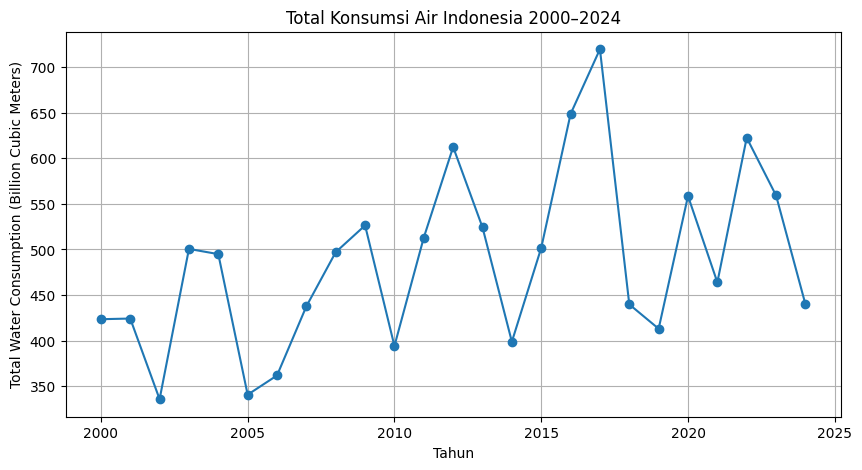

In [7]:
# Contoh 1 negara: Indonesia
df_indo = df[df["Country"] == "Indonesia"]
plt.figure(figsize=(10,5))
plt.plot(df_indo["Year"], df_indo["Total Water Consumption (Billion Cubic Meters)"], marker="o")
plt.title("Total Konsumsi Air Indonesia 2000–2024")
plt.xlabel("Tahun")
plt.ylabel("Total Water Consumption (Billion Cubic Meters)")
plt.grid(True)
plt.show()

**3. Bagaimana perbedaan rata-rata konsumsi air, curah hujan, dan penurunan air tanah pada setiap tingkat kelangkaan air?**

| Water Scarcity Level | Rata-rata Total Konsumsi (miliar m³) | Rata-rata Per Capita (L/hari) | Rata-rata Curah Hujan (mm) | Rata-rata Penurunan Air Tanah (%) |
|---|---|---|---|---|
| High | 457.99 | 177.77 | 1585.88 | 2.56 |
| Low | 494.08 | 328.94 | 1567.30 | 2.57 |
| Moderate | 505.81 | 262.98 | 1535.16 | 2.58 |

Kelompok dengan kelangkaan **High** memiliki rata-rata penurunan air tanah **[lebih tinggi/lebih rendah]** dibanding kelompok **Low**, yang menandakan tekanan air tanah lebih besar di negara-negara dengan kelangkaan tinggi.

In [8]:
# Rata-rata per level kelangkaan
group_summary = df.groupby("Water Scarcity Level")[["Total Water Consumption (Billion Cubic Meters)", "Per Capita Water Use (Liters per Day)", "Rainfall Impact (Annual Precipitation in mm)", "Groundwater Depletion Rate (%)"]].mean()
display(group_summary.round(2))

,Total Water Consumption (Billion Cubic Meters),Per Capita Water Use (Liters per Day),Rainfall Impact (Annual Precipitation in mm),Groundwater Depletion Rate (%)
Water Scarcity Level,,,,
High,457.99,177.77,1585.88,2.56
Low,494.08,328.94,1567.30,2.57
Moderate,505.81,262.98,1535.16,2.58


### 5 Temuan Paling Menarik

1. Sebagian besar data (72,0%) berada pada tingkat kelangkaan **Moderate**, hanya 3,6% yang **High**. Artinya mayoritas negara berada di zona waspada.
2. Rata-rata **total konsumsi air** 501,22 miliar m³ (median 502,20) sebaran simetris, tidak ada outlier ekstrem.
3. Rata-rata **per capita water use** 276,00 liter/hari, dengan variasi sedang (simpangan baku 42,67).
4. Rata-rata **curah hujan tahunan** 1.544,82 mm, tetapi variasinya paling besar (simpangan baku 292,79; IQR 392,67) curah hujan antar negara sangat berbeda.
5. Sektor **pertanian** mendominasi penggunaan air, sementara **rumah tangga** porsinya paling kecil.

### Keterbatasan Data

- Data berlevel **negara**, bukan kota, sehingga kurang cocok untuk analisis smart city secara granular.
- Persentase sektor (pertanian + industri + rumah tangga) pada beberapa baris jika dijumlahkan bisa lebih dari 100%, sehingga perlu kehati-hatian dalam menafsirkan.
- Penjelasan **cara pengumpulan data tidak tertera** di sumber Kaggle, sehingga kualitas datanya sulit diverifikasi.
- Nilai **modus** di beberapa kolom sama dengan **nilai minimum**, artinya distribusi frekuensinya kurang ideal untuk analisis modus.

### Ide Pertanyaan Lanjutan

- Apakah negara dengan **curah hujan tinggi** selalu memiliki **groundwater depletion rate rendah**? (uji korelasi)
- Apakah ada **tren linear** antara tahun dan total konsumsi air di negara-negara tertentu? (analisis regresi untuk Proyek Akhir)
- Apakah **negara dengan agricultural water use tinggi** cenderung punya **water scarcity level buruk**?
- Bagaimana **perbandingan per capita water use** antara negara maju dan berkembang?

## Referensi dan Catatan Penggunaan AI

### Sumber Dataset

- **Nama:** Global Water Consumption Dataset 2000–2024
- **Sumber:** Kaggle
- **Link:** https://www.kaggle.com/datasets/atharvasoundankar/global-water-consumption-dataset-2000-2024
- **Lisensi:** No Copyright
- **Kontributor:** Atharva Soundankar
- **Periode:** 2000–2024

### Catatan Penggunaan AI

| Alat | Dipakai untuk | Yang kami pelajari |
|---|---|---|
| DEEPSEEK | Menanyakan errorCondaToSNonInteractiveError: Terms of Service have not been accepted for the following channels. | Kami belum menerima terms of service dari Anaconda Prompt |
| DEEPSEEK | Menanyakan error FileNotFoundError Traceback (most recent call last) | Nama file dataset di project arkan berbeda dengan dataset yang ada di project utama |